In [60]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

In [64]:
import warnings
warnings.filterwarnings('ignore')

In [4]:
from sklearn.datasets import load_iris

iris = load_iris()

In [8]:
iris

{'data': array([[5.1, 3.5, 1.4, 0.2],
        [4.9, 3. , 1.4, 0.2],
        [4.7, 3.2, 1.3, 0.2],
        [4.6, 3.1, 1.5, 0.2],
        [5. , 3.6, 1.4, 0.2],
        [5.4, 3.9, 1.7, 0.4],
        [4.6, 3.4, 1.4, 0.3],
        [5. , 3.4, 1.5, 0.2],
        [4.4, 2.9, 1.4, 0.2],
        [4.9, 3.1, 1.5, 0.1],
        [5.4, 3.7, 1.5, 0.2],
        [4.8, 3.4, 1.6, 0.2],
        [4.8, 3. , 1.4, 0.1],
        [4.3, 3. , 1.1, 0.1],
        [5.8, 4. , 1.2, 0.2],
        [5.7, 4.4, 1.5, 0.4],
        [5.4, 3.9, 1.3, 0.4],
        [5.1, 3.5, 1.4, 0.3],
        [5.7, 3.8, 1.7, 0.3],
        [5.1, 3.8, 1.5, 0.3],
        [5.4, 3.4, 1.7, 0.2],
        [5.1, 3.7, 1.5, 0.4],
        [4.6, 3.6, 1. , 0.2],
        [5.1, 3.3, 1.7, 0.5],
        [4.8, 3.4, 1.9, 0.2],
        [5. , 3. , 1.6, 0.2],
        [5. , 3.4, 1.6, 0.4],
        [5.2, 3.5, 1.5, 0.2],
        [5.2, 3.4, 1.4, 0.2],
        [4.7, 3.2, 1.6, 0.2],
        [4.8, 3.1, 1.6, 0.2],
        [5.4, 3.4, 1.5, 0.4],
        [5.2, 4.1, 1.5, 0.1],
  

In [10]:
df = pd.DataFrame(iris.data,columns=iris.feature_names)

In [12]:
df

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2
...,...,...,...,...
145,6.7,3.0,5.2,2.3
146,6.3,2.5,5.0,1.9
147,6.5,3.0,5.2,2.0
148,6.2,3.4,5.4,2.3


In [14]:
df.describe()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333
std,0.828066,0.435866,1.765298,0.762238
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


In [16]:
df.isna().sum().sum()

0

In [18]:
df.duplicated().sum()

1

In [24]:
df.drop_duplicates(inplace=True)

In [26]:
df.duplicated().sum()

0

In [28]:
corr_matrix = df.corr()

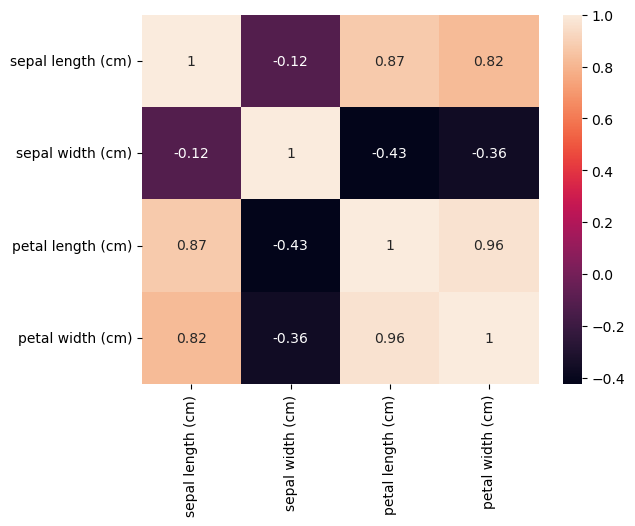

In [30]:
sns.heatmap(corr_matrix, annot = True)
plt.show()

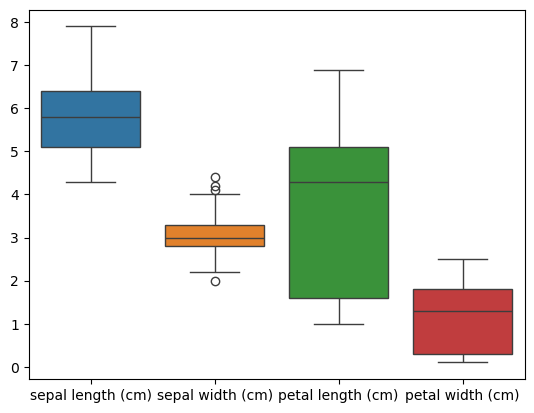

In [36]:
sns.boxplot(df)
plt.show()

In [40]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(df)

In [50]:
X_scaled

array([[-0.8980334 ,  1.01240113, -1.33325507, -1.30862368],
       [-1.13956224, -0.1373532 , -1.33325507, -1.30862368],
       [-1.38109108,  0.32254853, -1.39001364, -1.30862368],
       [-1.5018555 ,  0.09259766, -1.2764965 , -1.30862368],
       [-1.01879782,  1.242352  , -1.33325507, -1.30862368],
       [-0.53574014,  1.9322046 , -1.16297935, -1.04548613],
       [-1.5018555 ,  0.78245027, -1.33325507, -1.17705491],
       [-1.01879782,  0.78245027, -1.2764965 , -1.30862368],
       [-1.74338434, -0.36730407, -1.33325507, -1.30862368],
       [-1.13956224,  0.09259766, -1.2764965 , -1.44019246],
       [-0.53574014,  1.47230287, -1.2764965 , -1.30862368],
       [-1.26032666,  0.78245027, -1.21973792, -1.30862368],
       [-1.26032666, -0.1373532 , -1.33325507, -1.44019246],
       [-1.86414876, -0.1373532 , -1.50353079, -1.44019246],
       [-0.05268246,  2.16215547, -1.44677222, -1.30862368],
       [-0.17344688,  3.08195894, -1.2764965 , -1.04548613],
       [-0.53574014,  1.

In [44]:
X_scaled.mean(axis=0)

array([-2.30324708e-15, -1.95127285e-15, -1.37771971e-15, -1.18696999e-15])

In [48]:
X_scaled.std(axis=0)

array([1., 1., 1., 1.])

OPTIMAL K

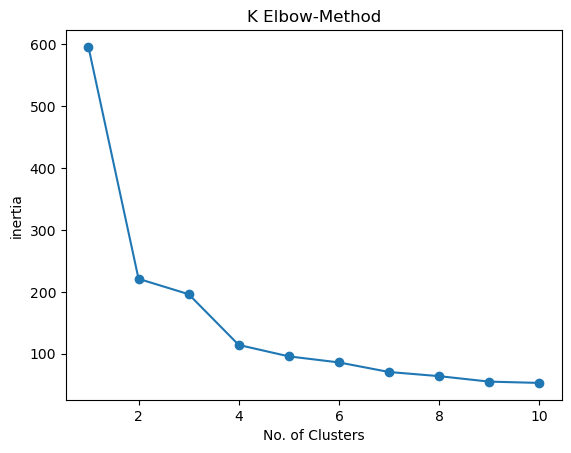

In [66]:
from sklearn.cluster import KMeans

inertia = []

for k in range(1,11):

    model = KMeans(
        n_clusters = k,
        random_state = 42
    )

    model.fit(X_scaled)
    
    inertia.append(model.inertia_)


plt.plot(
    range(1,11),
    inertia,
    marker = 'o'
)

plt.title("K Elbow-Method")
plt.xlabel("No. of Clusters")
plt.ylabel("inertia")
plt.show()

Silhouette Score

In [68]:
from sklearn.metrics import silhouette_score

for k in range(2,11):

    model = KMeans(
        n_clusters = k,
        random_state = 42
    )

    labels = model.fit_predict(X_scaled)

    score = silhouette_score(
        X_scaled, labels
    )

    print(f"K : {k} , Score : {score} ")

K : 2 , Score : 0.5810395072315083 
K : 3 , Score : 0.49387101479382844 
K : 4 , Score : 0.3985900404567473 
K : 5 , Score : 0.34212959041287433 
K : 6 , Score : 0.3318414761655934 
K : 7 , Score : 0.32717193500941616 
K : 8 , Score : 0.3383123084789235 
K : 9 , Score : 0.33308359769824836 
K : 10 , Score : 0.305246383885222 


Train the model

In [71]:
kmeans = KMeans(
    n_clusters = 3,
    random_state = 42
)

clusters = kmeans.fit_predict(X_scaled)

df['cluster'] = clusters


In [73]:
df.groupby('cluster').mean()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
cluster,,,,
0,6.266667,2.873737,4.904040,1.673737
1,4.878378,3.259459,1.440541,0.232432
2,5.369231,3.907692,1.523077,0.284615


In [75]:
df['cluster'].value_counts()

cluster
0    99
1    37
2    13
Name: count, dtype: int64

PCA visualization

In [88]:
from sklearn.decomposition import PCA

pca = PCA(n_components = 2)

X_pca = pca.fit_transform(X_scaled)

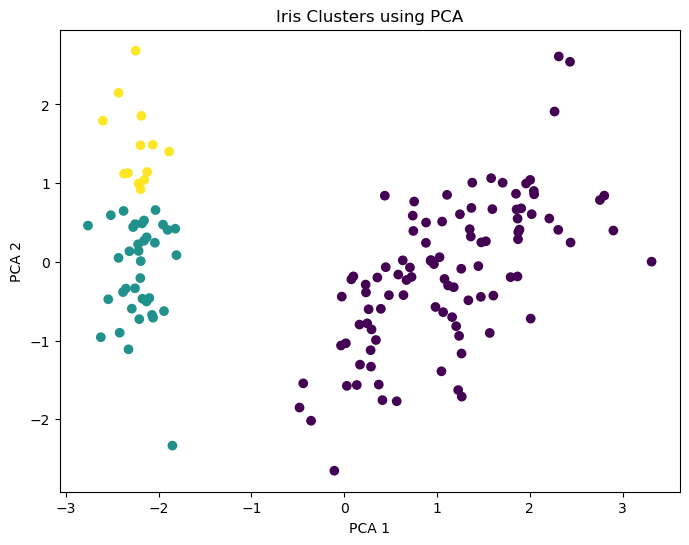

In [90]:
plt.figure(figsize=(8,6))

plt.scatter(
    X_pca[:,0],
    X_pca[:,1],
    c=clusters
)
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.title("Iris Clusters using PCA")

plt.show()

In [92]:
print(pca.explained_variance_ratio_)

[0.72991022 0.22858172]
